In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE, ADASYN, KMeansSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, NearMiss, ClusterCentroids
from imblearn.combine import SMOTEENN

# Load the dataset
df = pd.read_csv(r"T:\00 445\student\student-mat.csv", sep=";")

# Create binary target variable: 1 = Pass (G3 ≥ 10), 0 = Fail
df['pass'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)


#df.drop(columns=['G2','Medu','Fedu','studytime','famrel', 'G3'], inplace=True)
#df.drop(columns=['G2','G1', 'G3'], inplace=True)
#df.drop(columns=['G1','G2','Medu','Fedu','studytime','famrel', 'G3'], inplace=True)
df.drop(columns=['G2','G3'], inplace=True)
#df.drop(columns=['G3'], inplace=True)

# Separate features and target
X = df.drop(columns=['pass'])
y = df['pass']

# One-Hot Encoding for categorical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
column_transformer = ColumnTransformer([("onehot", OneHotEncoder(drop='first'), categorical_cols)], remainder='passthrough')

# Transform the dataset
X_encoded = column_transformer.fit_transform(X)

# Convert the transformed data back to DataFrame
X_df = pd.DataFrame(X_encoded.toarray() if hasattr(X_encoded, 'toarray') else X_encoded)

# Split the dataset: 80% train, 5% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X_df, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.55, stratify=y_temp, random_state=42)


# Flag to choose the sampling technique
SAMPLING_TECHNIQUE = 'ADASYN'
  # Options: 'SMOTE', 'ADASYN', 'SMOTEENN', 'UnderSampling', 'TomekLinks', 'NearMiss', 'ClusterCentroids', 'KMeansSMOTE'

# Apply selected sampling technique
if SAMPLING_TECHNIQUE == 'SMOTE':
    smote = SMOTE(random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
    print("After SMOTE:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'ADASYN':
    adasyn = ADASYN(random_state=42)
    X_train_bal, y_train_bal = adasyn.fit_resample(X_train, y_train)
    print("After ADASYN:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'SMOTEENN':
    smote_enn = SMOTEENN(random_state=42)
    X_train_bal, y_train_bal = smote_enn.fit_resample(X_train, y_train)
    print("After SMOTEENN:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'UnderSampling':
    undersampler = RandomUnderSampler(random_state=42)
    X_train_bal, y_train_bal = undersampler.fit_resample(X_train, y_train)
    print("After Under-sampling:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'TomekLinks':
    tomek = TomekLinks()
    X_train_bal, y_train_bal = tomek.fit_resample(X_train, y_train)
    print("After Tomek Links:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'NearMiss':
    near_miss = NearMiss(version=1)  # Use version 1, 2, or 3
    X_train_bal, y_train_bal = near_miss.fit_resample(X_train, y_train)
    print("After NearMiss:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'ClusterCentroids':
    cluster_centroids = ClusterCentroids(random_state=42)
    X_train_bal, y_train_bal = cluster_centroids.fit_resample(X_train, y_train)
    print("After Cluster Centroids:")
    print(pd.Series(y_train_bal).value_counts())
elif SAMPLING_TECHNIQUE == 'KMeansSMOTE':
    kmeans_smote = KMeansSMOTE(random_state=42)
    X_train_bal, y_train_bal = kmeans_smote.fit_resample(X_train, y_train)
    print("After KMeansSMOTE:")
    print(pd.Series(y_train_bal).value_counts())
else:
    # If no sampling technique is selected, use the original training data
    X_train_bal, y_train_bal = X_train, y_train

# Standardize features for training, validation, and test sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# You can now proceed with model training (e.g., Decision Tree, Random Forest, etc.)


After ADASYN:
pass
0    199
1    185
Name: count, dtype: int64


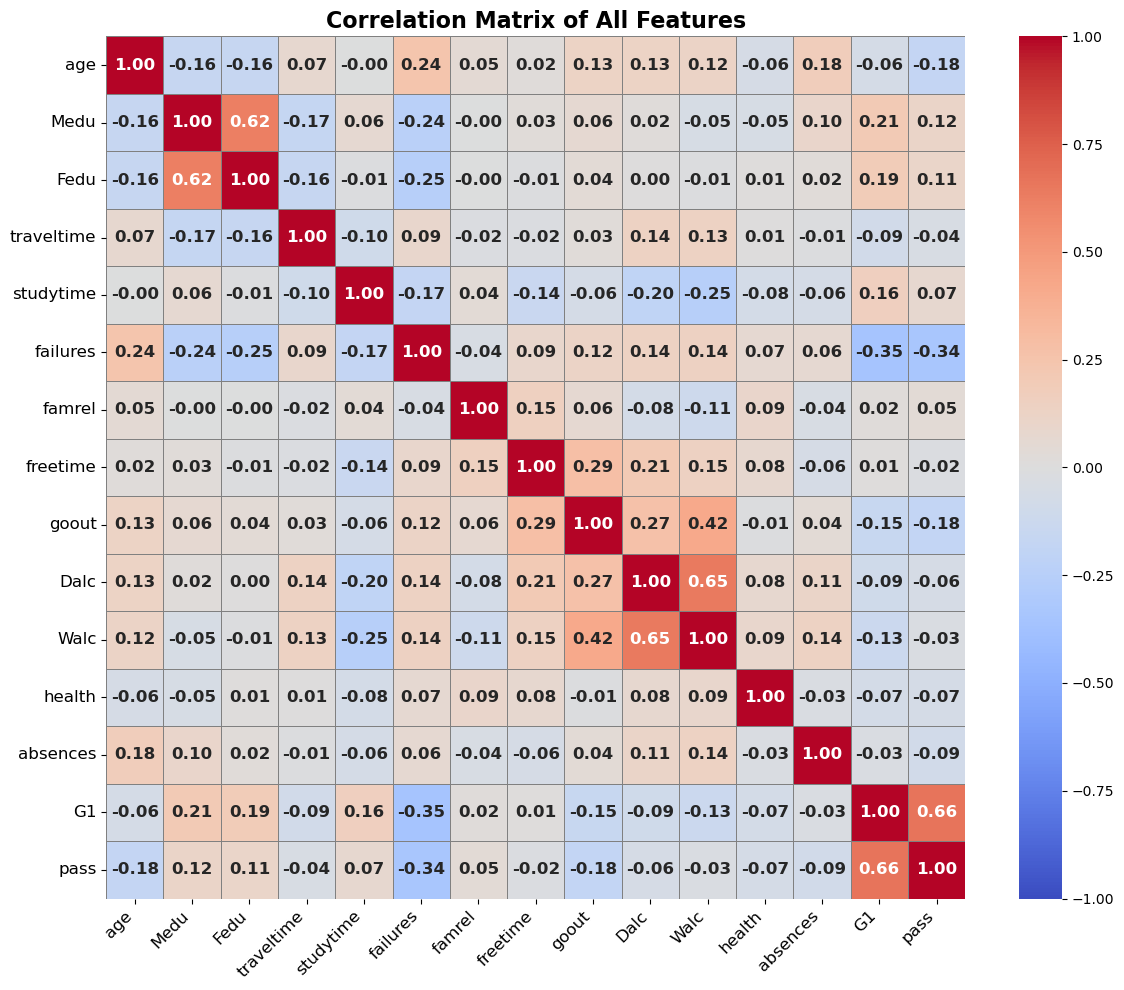

Correlation matrix of all features:
                 age      Medu      Fedu  traveltime  studytime  failures  \
age         1.000000 -0.163658 -0.163438    0.070641  -0.004140  0.243665   
Medu       -0.163658  1.000000  0.623455   -0.171639   0.064944 -0.236680   
Fedu       -0.163438  0.623455  1.000000   -0.158194  -0.009175 -0.250408   
traveltime  0.070641 -0.171639 -0.158194    1.000000  -0.100909  0.092239   
studytime  -0.004140  0.064944 -0.009175   -0.100909   1.000000 -0.173563   
failures    0.243665 -0.236680 -0.250408    0.092239  -0.173563  1.000000   
famrel      0.053940 -0.003914 -0.001370   -0.016808   0.039731 -0.044337   
freetime    0.016434  0.030891 -0.012846   -0.017025  -0.143198  0.091987   
goout       0.126964  0.064094  0.043105    0.028540  -0.063904  0.124561   
Dalc        0.131125  0.019834  0.002386    0.138325  -0.196019  0.136047   
Walc        0.117276 -0.047123 -0.012631    0.134116  -0.253785  0.141962   
health     -0.062187 -0.046878  0.014742

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# Step 1: Select only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate the correlation matrix for all numerical columns
correlation_matrix_all = df[numerical_cols].corr()

# Step 2: Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))  # Increase figure size for better readability
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, annot_kws={'size': 12, 'weight': 'bold'}, 
            linewidths=0.5, linecolor='gray', vmin=-1, vmax=1)  # Added grid lines and color scale range
plt.title("Correlation Matrix of All Features", fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)  # Rotate x-axis labels for better visibility
plt.yticks(rotation=0, ha='right', fontsize=12)  # Keep y-axis labels horizontal for clarity
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

# Step 3: Print the full correlation matrix
print("Correlation matrix of all features:")
print(correlation_matrix_all)


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.60      0.53      0.56        17
           1       0.79      0.83      0.81        36

    accuracy                           0.74        53
   macro avg       0.69      0.68      0.69        53
weighted avg       0.73      0.74      0.73        53


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.67      0.73      0.70        22
           1       0.86      0.82      0.84        44

    accuracy                           0.79        66
   macro avg       0.76      0.77      0.77        66
weighted avg       0.79      0.79      0.79        66


Accuracy Comparison:
Validation Accuracy: 0.7358
Test Accuracy: 0.7879


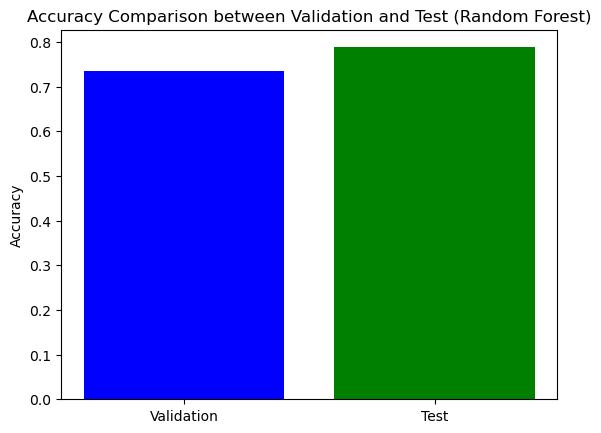

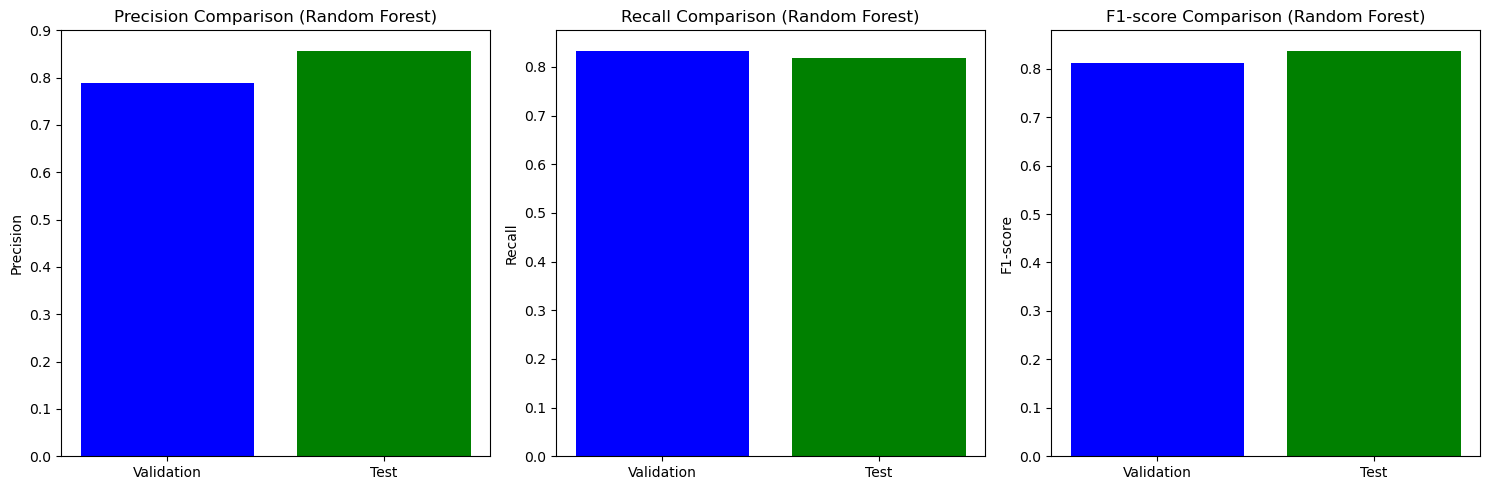

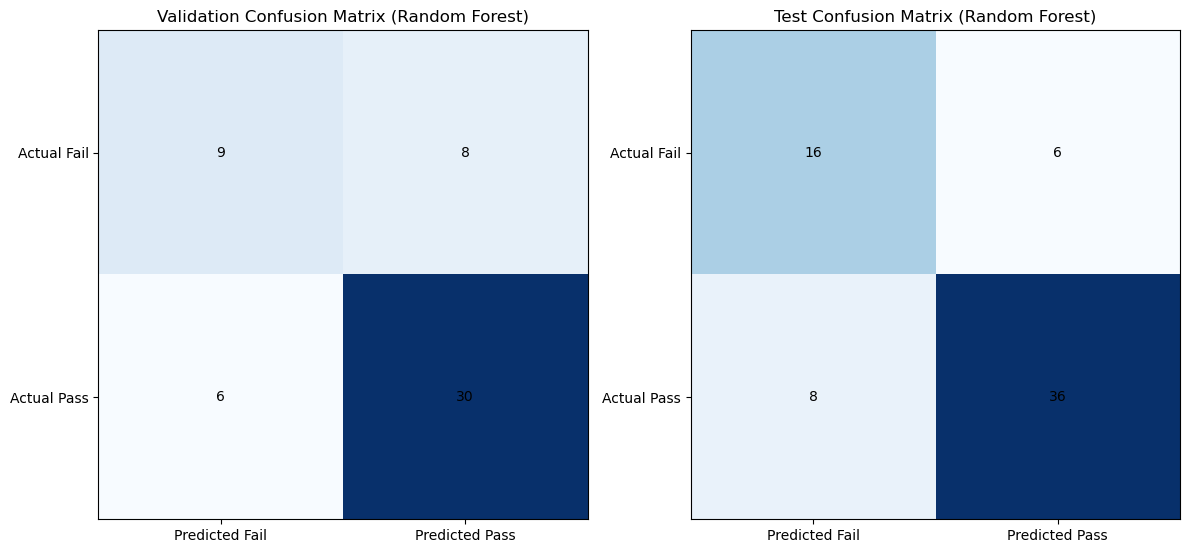

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Initialize Random Forest Classifier with default settings
rf_model = RandomForestClassifier(random_state=42)

# Train the model on the balanced, scaled training data
rf_model.fit(X_train_scaled, y_train_bal)

# Predictions on validation and test sets
y_val_pred_rf = rf_model.predict(X_val_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Calculate classification metrics
val_report_rf = classification_report(y_val, y_val_pred_rf, output_dict=True)
test_report_rf = classification_report(y_test, y_test_pred_rf, output_dict=True)

# Accuracy comparison
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

# Display classification report for validation set in the requested format
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_rf))

# Display classification report for test set in the requested format
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_rf))

# Display accuracy for validation and test sets
print("\nAccuracy Comparison:")
print(f"Validation Accuracy: {val_accuracy_rf:.4f}")
print(f"Test Accuracy: {test_accuracy_rf:.4f}")

# Plotting accuracy comparison between validation and test sets
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_rf, test_accuracy_rf], color=['blue', 'green'])
ax.set_title('Accuracy Comparison between Validation and Test (Random Forest)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison: precision, recall, and F1-score
metrics = ['precision', 'recall', 'f1-score']
metrics_values_rf = {metric: [val_report_rf['1'][metric], test_report_rf['1'][metric]] for metric in metrics}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(metrics):
    ax[i].bar(['Validation', 'Test'], metrics_values_rf[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison (Random Forest)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the Random Forest model with annotations
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_rf = confusion_matrix(y_val, y_val_pred_rf)
ax[0].imshow(val_conf_matrix_rf, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (Random Forest)')
for i in range(val_conf_matrix_rf.shape[0]):
    for j in range(val_conf_matrix_rf.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_rf[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_rf = confusion_matrix(y_test, y_test_pred_rf)
ax[1].imshow(test_conf_matrix_rf, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (Random Forest)')
for i in range(test_conf_matrix_rf.shape[0]):
    for j in range(test_conf_matrix_rf.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_rf[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


Best Parameters for Random Forest: {'bootstrap': False, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


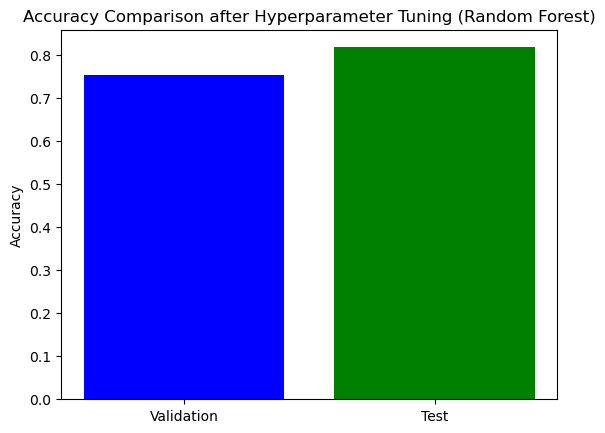

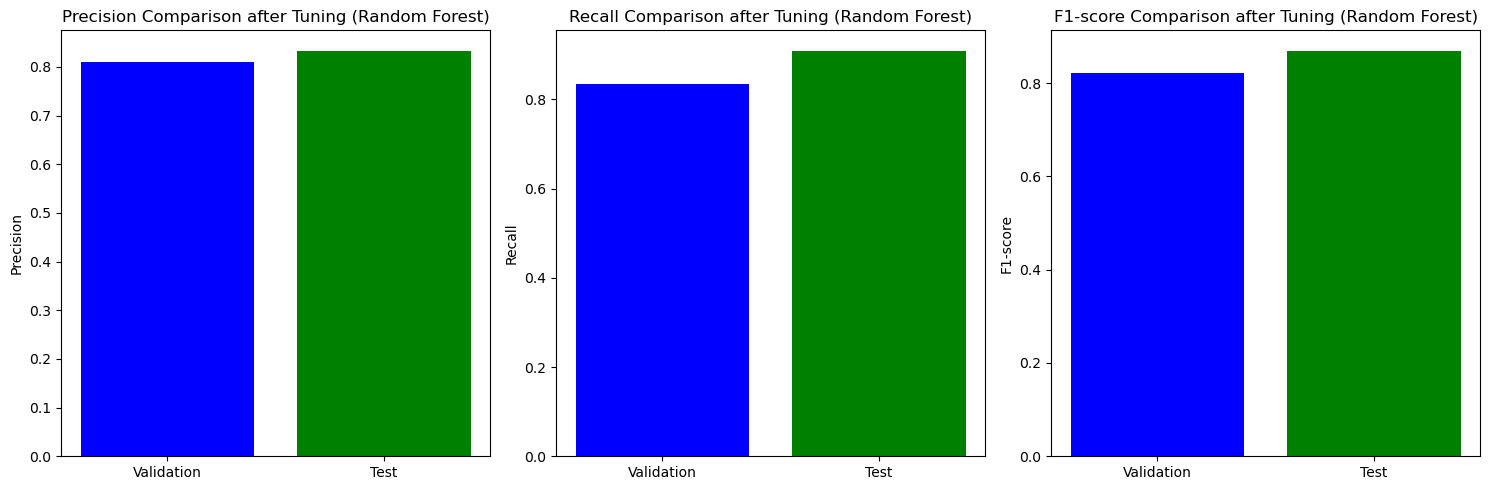

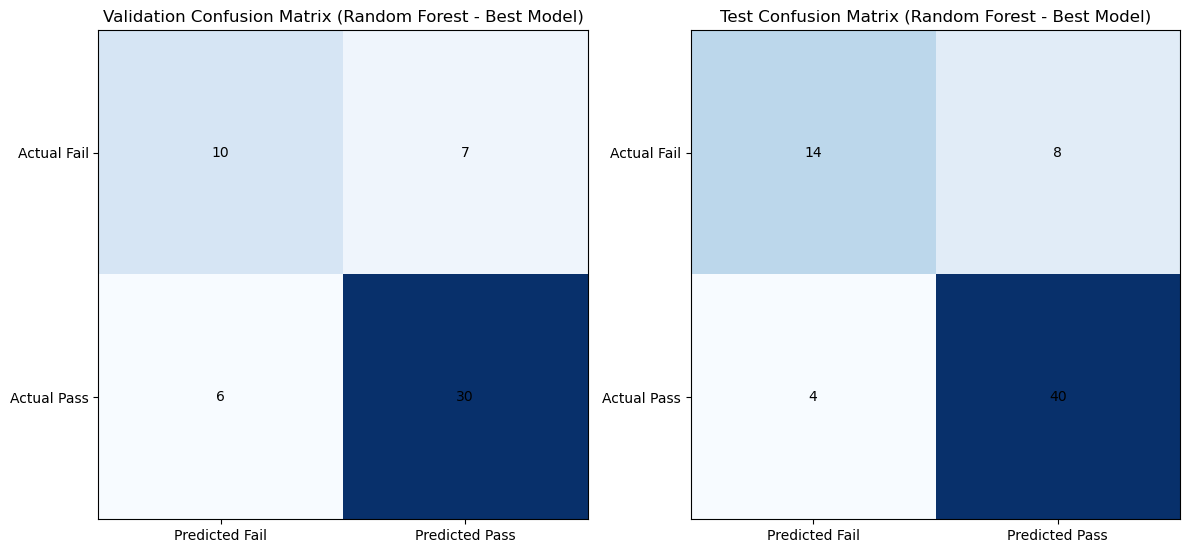

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd

# Initialize Random Forest Classifier with class_weight='balanced' for class imbalance handling
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Updated parameter grid to align with previous suggestions
param_grid_rf = {
    "n_estimators": [50, 100, 200],             # Start with a reasonable range of estimators
    "max_depth": [3, 5, 10, 15, None],          # Restrict tree depth to prevent overfitting
    "min_samples_split": [2, 5, 10],             # Control the minimum samples required to split a node
    "min_samples_leaf": [1, 2, 4],               # Control the minimum samples required to be at a leaf node
    "max_features": ["sqrt", "log2", None],     # Limit the number of features to consider at each split
    "bootstrap": [True, False]                   # Bootstrap sampling; True is often better for Random Forest
}

# Initialize GridSearchCV with 5-fold cross-validation and recall as scoring metric
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, n_jobs=-1, scoring='recall')

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_scaled, y_train_bal)

# Best parameters from grid search
best_params_rf = grid_search_rf.best_params_
print("Best Parameters for Random Forest:", best_params_rf)

# Best model from grid search
best_rf_model = grid_search_rf.best_estimator_

# Predictions on validation and test sets with the best model
y_val_pred_rf_best = best_rf_model.predict(X_val_scaled)
y_test_pred_rf_best = best_rf_model.predict(X_test_scaled)

# Classification metrics for the tuned model
val_report_rf_best = classification_report(y_val, y_val_pred_rf_best, output_dict=True)
test_report_rf_best = classification_report(y_test, y_test_pred_rf_best, output_dict=True)

# Accuracy comparison after hyperparameter tuning
val_accuracy_rf_best = accuracy_score(y_val, y_val_pred_rf_best)
test_accuracy_rf_best = accuracy_score(y_test, y_test_pred_rf_best)

# Plotting accuracy comparison after hyperparameter tuning
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_rf_best, test_accuracy_rf_best], color=['blue', 'green'])
ax.set_title('Accuracy Comparison after Hyperparameter Tuning (Random Forest)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison after tuning: precision, recall, and F1-score
metrics = ['precision', 'recall', 'f1-score']
metrics_values_rf_best = {metric: [val_report_rf_best['1'][metric], test_report_rf_best['1'][metric]] for metric in metrics}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(metrics):
    ax[i].bar(['Validation', 'Test'], metrics_values_rf_best[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison after Tuning (Random Forest)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the best model with annotations in black font
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_rf_best = confusion_matrix(y_val, y_val_pred_rf_best)
ax[0].imshow(val_conf_matrix_rf_best, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (Random Forest - Best Model)')
for i in range(val_conf_matrix_rf_best.shape[0]):
    for j in range(val_conf_matrix_rf_best.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_rf_best[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_rf_best = confusion_matrix(y_test, y_test_pred_rf_best)
ax[1].imshow(test_conf_matrix_rf_best, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (Random Forest - Best Model)')
for i in range(test_conf_matrix_rf_best.shape[0]):
    for j in range(test_conf_matrix_rf_best.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_rf_best[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()


Classification Report (Validation Set):
              precision    recall  f1-score   support

           0       0.69      0.65      0.67        17
           1       0.84      0.86      0.85        36

    accuracy                           0.79        53
   macro avg       0.76      0.75      0.76        53
weighted avg       0.79      0.79      0.79        53


Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.65      0.77      0.71        22
           1       0.88      0.80      0.83        44

    accuracy                           0.79        66
   macro avg       0.76      0.78      0.77        66
weighted avg       0.80      0.79      0.79        66


Accuracy Comparison:
Validation Accuracy: 0.7925
Test Accuracy: 0.7879


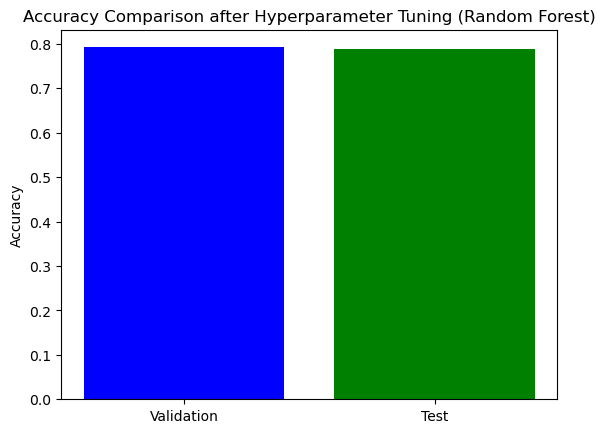

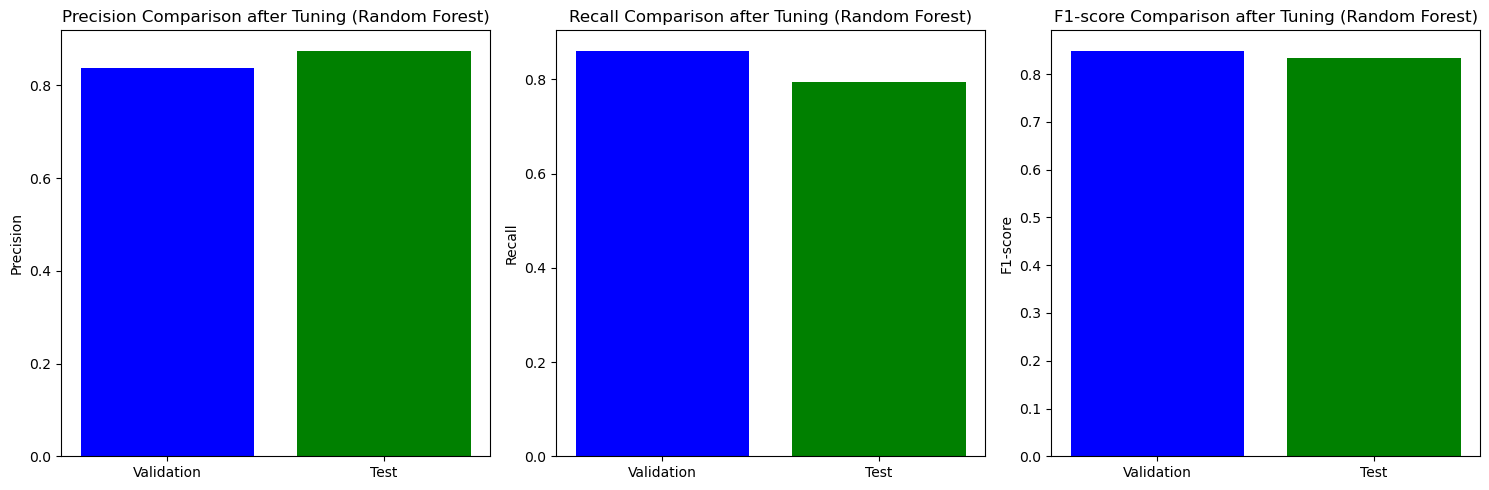

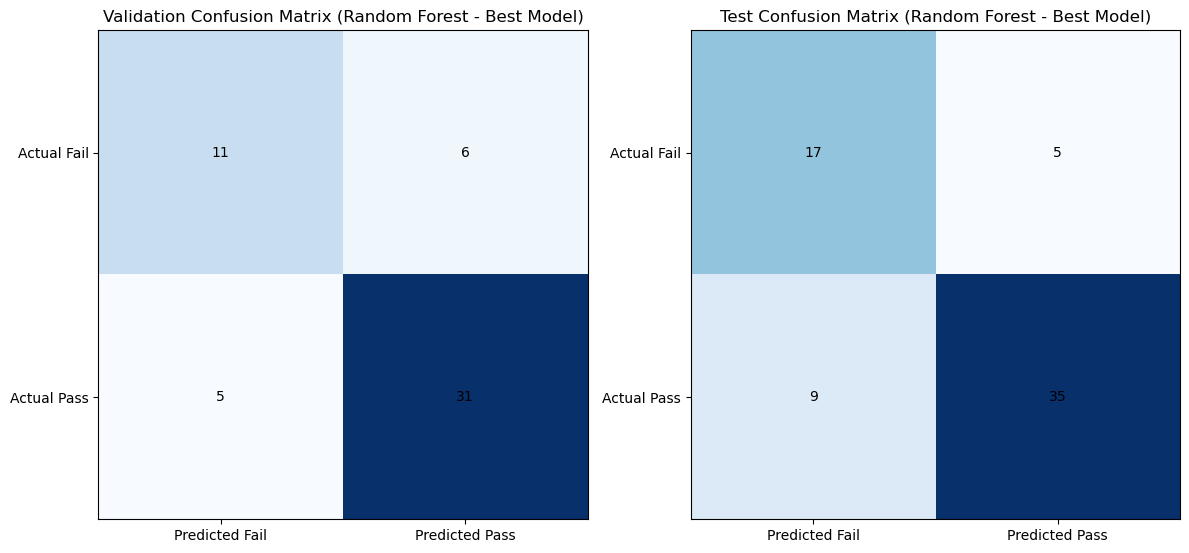

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd

# Best Parameters for Random Forest
best_rf_params = {
    'bootstrap': True,
    'max_depth': 10,
    'max_features': 'sqrt',
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 50
}

# Initialize Random Forest Classifier with the best hyperparameters
best_rf_model = RandomForestClassifier(**best_rf_params, random_state=42)

# Train the model on the balanced, scaled training data
best_rf_model.fit(X_train_scaled, y_train_bal)

# Predictions on validation and test sets with the best model
y_val_pred_rf_best = best_rf_model.predict(X_val_scaled)
y_test_pred_rf_best = best_rf_model.predict(X_test_scaled)

# Classification metrics for the tuned model
val_report_rf_best = classification_report(y_val, y_val_pred_rf_best, output_dict=True)
test_report_rf_best = classification_report(y_test, y_test_pred_rf_best, output_dict=True)

# Accuracy comparison after hyperparameter tuning
val_accuracy_rf_best = accuracy_score(y_val, y_val_pred_rf_best)
test_accuracy_rf_best = accuracy_score(y_test, y_test_pred_rf_best)

# Print Classification Report for Validation Set
print("Classification Report (Validation Set):")
print(classification_report(y_val, y_val_pred_rf_best))

# Print Classification Report for Test Set
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_rf_best))

# Print Accuracy Comparison
print("\nAccuracy Comparison:")
print(f"Validation Accuracy: {val_accuracy_rf_best:.4f}")
print(f"Test Accuracy: {test_accuracy_rf_best:.4f}")

# Plotting accuracy comparison after hyperparameter tuning
fig, ax = plt.subplots()
ax.bar(['Validation', 'Test'], [val_accuracy_rf_best, test_accuracy_rf_best], color=['blue', 'green'])
ax.set_title('Accuracy Comparison after Hyperparameter Tuning (Random Forest)')
ax.set_ylabel('Accuracy')
plt.show()

# Plotting other metrics comparison after tuning: precision, recall, and F1-score
metrics_values_rf_best = {metric: [val_report_rf_best['1'][metric], test_report_rf_best['1'][metric]] for metric in ['precision', 'recall', 'f1-score']}

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['precision', 'recall', 'f1-score']):
    ax[i].bar(['Validation', 'Test'], metrics_values_rf_best[metric], color=['blue', 'green'])
    ax[i].set_title(f'{metric.capitalize()} Comparison after Tuning (Random Forest)')
    ax[i].set_ylabel(metric.capitalize())
plt.tight_layout()
plt.show()

# Plotting confusion matrix for the Random Forest model with annotations
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# For Validation Confusion Matrix
val_conf_matrix_rf_best = confusion_matrix(y_val, y_val_pred_rf_best)
ax[0].imshow(val_conf_matrix_rf_best, cmap='Blues', interpolation='nearest')
ax[0].set_title('Validation Confusion Matrix (Random Forest - Best Model)')
for i in range(val_conf_matrix_rf_best.shape[0]):
    for j in range(val_conf_matrix_rf_best.shape[1]):
        ax[0].text(j, i, str(val_conf_matrix_rf_best[i, j]), ha='center', va='center', color='black')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[0].set_yticklabels(['Actual Fail', 'Actual Pass'])

# For Test Confusion Matrix
test_conf_matrix_rf_best = confusion_matrix(y_test, y_test_pred_rf_best)
ax[1].imshow(test_conf_matrix_rf_best, cmap='Blues', interpolation='nearest')
ax[1].set_title('Test Confusion Matrix (Random Forest - Best Model)')
for i in range(test_conf_matrix_rf_best.shape[0]):
    for j in range(test_conf_matrix_rf_best.shape[1]):
        ax[1].text(j, i, str(test_conf_matrix_rf_best[i, j]), ha='center', va='center', color='black')
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['Predicted Fail', 'Predicted Pass'])
ax[1].set_yticklabels(['Actual Fail', 'Actual Pass'])

plt.tight_layout()
plt.show()
